# Khám phá dữ liệu PAD-UFES-20

Notebook này tập trung vào viêc khám phá dataset PAD-UFES-20 (Skin Cancer). Các bước thực hiện bao gồm:
- Tải dataset trực tiếp qua `kagglehub`.
- Kiểm tra dữ liệu khuyết thiếu (Missing Data).
- Khảo sát phân bố dữ liệu với `histplot`.
- Kiểm tra các giá trị ngoại lai với `boxplot`.
- Đánh giá ma trận tương quan giữa các đặc trưng.
- Lựa chọn đặc trưng cho biến mục tiêu dự đoán.

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

/Users/hhh/workspace/school/PBL7/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/hhh/workspace/school/PBL7/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Tải và Đọc Dữ Liệu

In [2]:
# Tải version mới nhất từ Kaggle
path = kagglehub.dataset_download("mahdavi1202/skin-cancer")
print("Path to dataset files:", path)

# Tìm và đọc file CSV (metadata)
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if len(csv_files) > 0:
    csv_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(csv_path)
    print(f"\nĐã tải file dữ liệu: {csv_files[0]}")
    display(df.head())
    print(f"\nKích thước tập dữ liệu: {df.shape}")
else:
    print("Không tìm thấy file CSV nào.\nCác file có trong thư mục:", os.listdir(path))

Path to dataset files: /Users/hhh/.cache/kagglehub/datasets/mahdavi1202/skin-cancer/versions/1

Đã tải file dữ liệu: metadata.csv


,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,...,diameter_2,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed
0,PAT_1516,1765,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,...,NaN,NEV,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,PAT_1516_1765_530.png,False
1,PAT_46,881,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,...,5.0,BCC,TRUE,TRUE,FALSE,TRUE,TRUE,TRUE,PAT_46_881_939.png,True
2,PAT_1545,1867,NaN,NaN,NaN,NaN,77,NaN,NaN,NaN,...,NaN,ACK,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,PAT_1545_1867_547.png,False
3,PAT_1989,4061,NaN,NaN,NaN,NaN,75,NaN,NaN,NaN,...,NaN,ACK,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,PAT_1989_4061_934.png,False
4,PAT_684,1302,False,True,POMERANIA,POMERANIA,79,False,MALE,True,...,5.0,BCC,TRUE,TRUE,FALSE,FALSE,TRUE,TRUE,PAT_684_1302_588.png,True



Kích thước tập dữ liệu: (2298, 26)


## 2. Kiểm tra Missing Data (Dữ liệu khuyết thiếu)

Các đặc trưng có dữ liệu bị thiếu:


,Missing Values,Percentage (%)
background_mother,822,35.770235
background_father,818,35.596171
smoke,804,34.986945
drink,804,34.986945
pesticide,804,34.986945
gender,804,34.986945
skin_cancer_history,804,34.986945
cancer_history,804,34.986945
has_piped_water,804,34.986945
has_sewage_system,804,34.986945


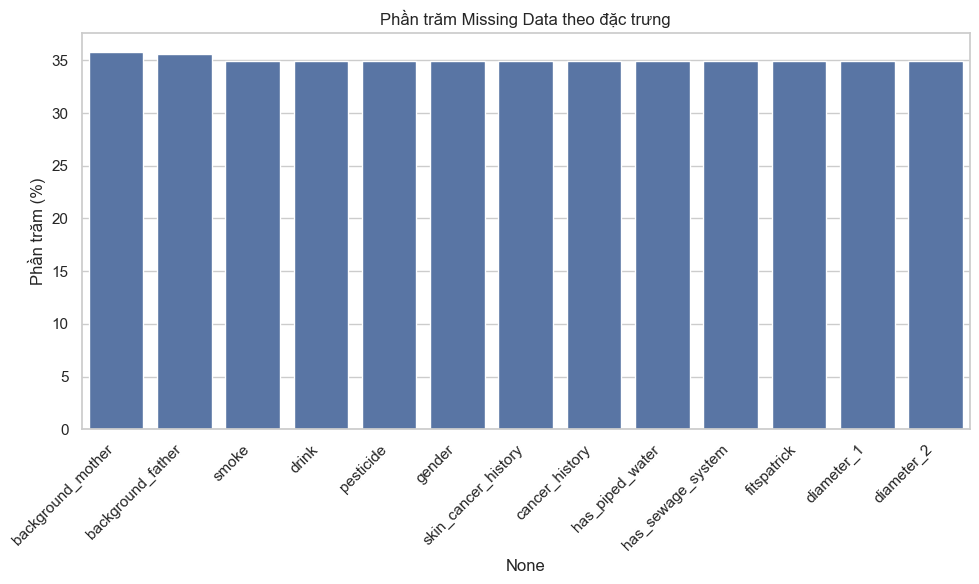

In [3]:
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_counts, 'Percentage (%)': missing_percent})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage (%)', ascending=False)

if not missing_df.empty:
    print("Các đặc trưng có dữ liệu bị thiếu:")
    display(missing_df)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_df.index, y=missing_df['Percentage (%)'])
    plt.xticks(rotation=45, ha='right')
    plt.title('Phần trăm Missing Data theo đặc trưng')
    plt.ylabel('Phần trăm (%)')
    plt.tight_layout()
    plt.show()
else:
    print("Không có đặc trưng nào bị thiếu dữ liệu (No missing data).")

## 3. Khám phá Phân phối biến (Histplot)

Biến dạng số (Numerical): ['lesion_id', 'age', 'fitspatrick', 'diameter_1', 'diameter_2']
Biến phân loại (Categorical): ['patient_id', 'smoke', 'drink', 'background_father', 'background_mother', 'pesticide', 'gender', 'skin_cancer_history', 'cancer_history', 'has_piped_water', 'has_sewage_system', 'region', 'diagnostic', 'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation', 'img_id']


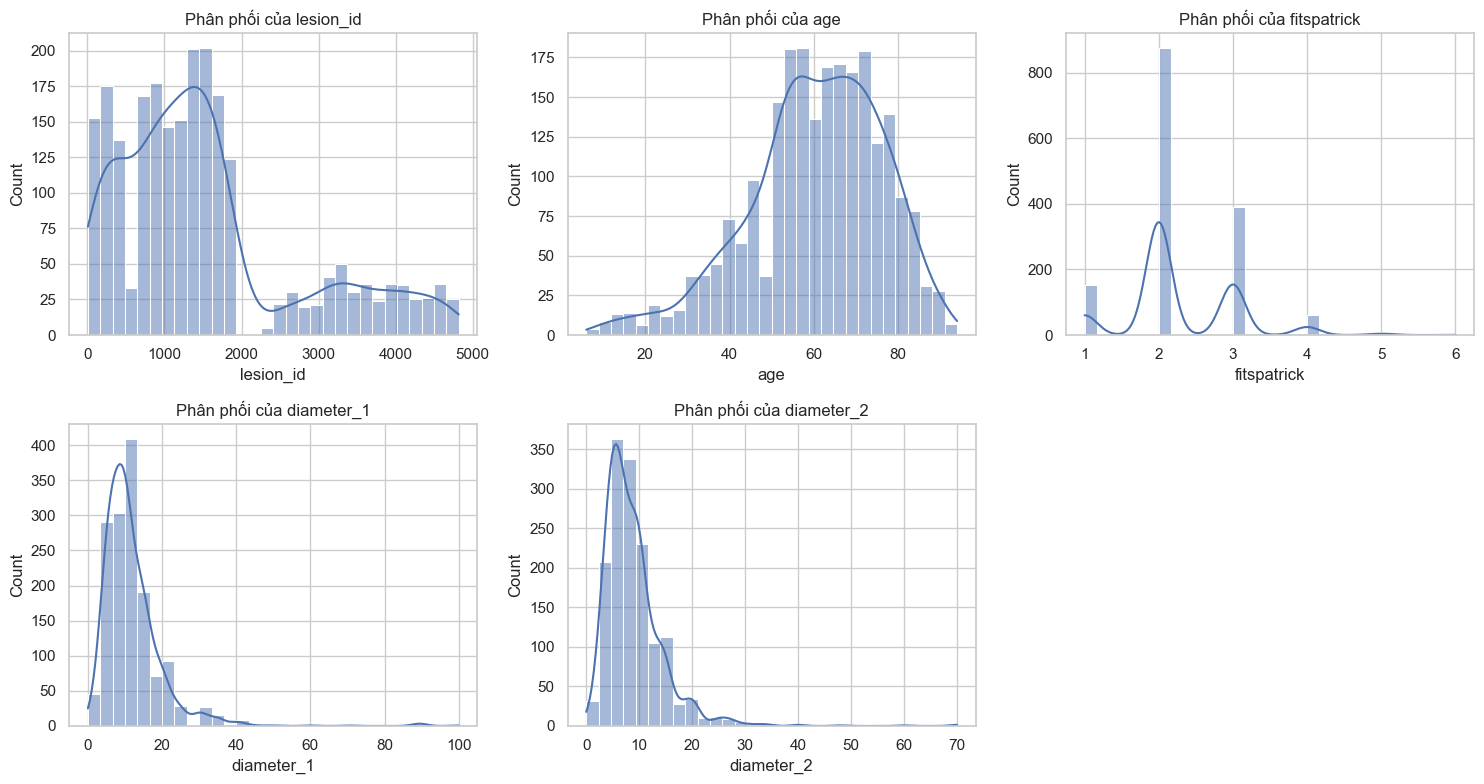

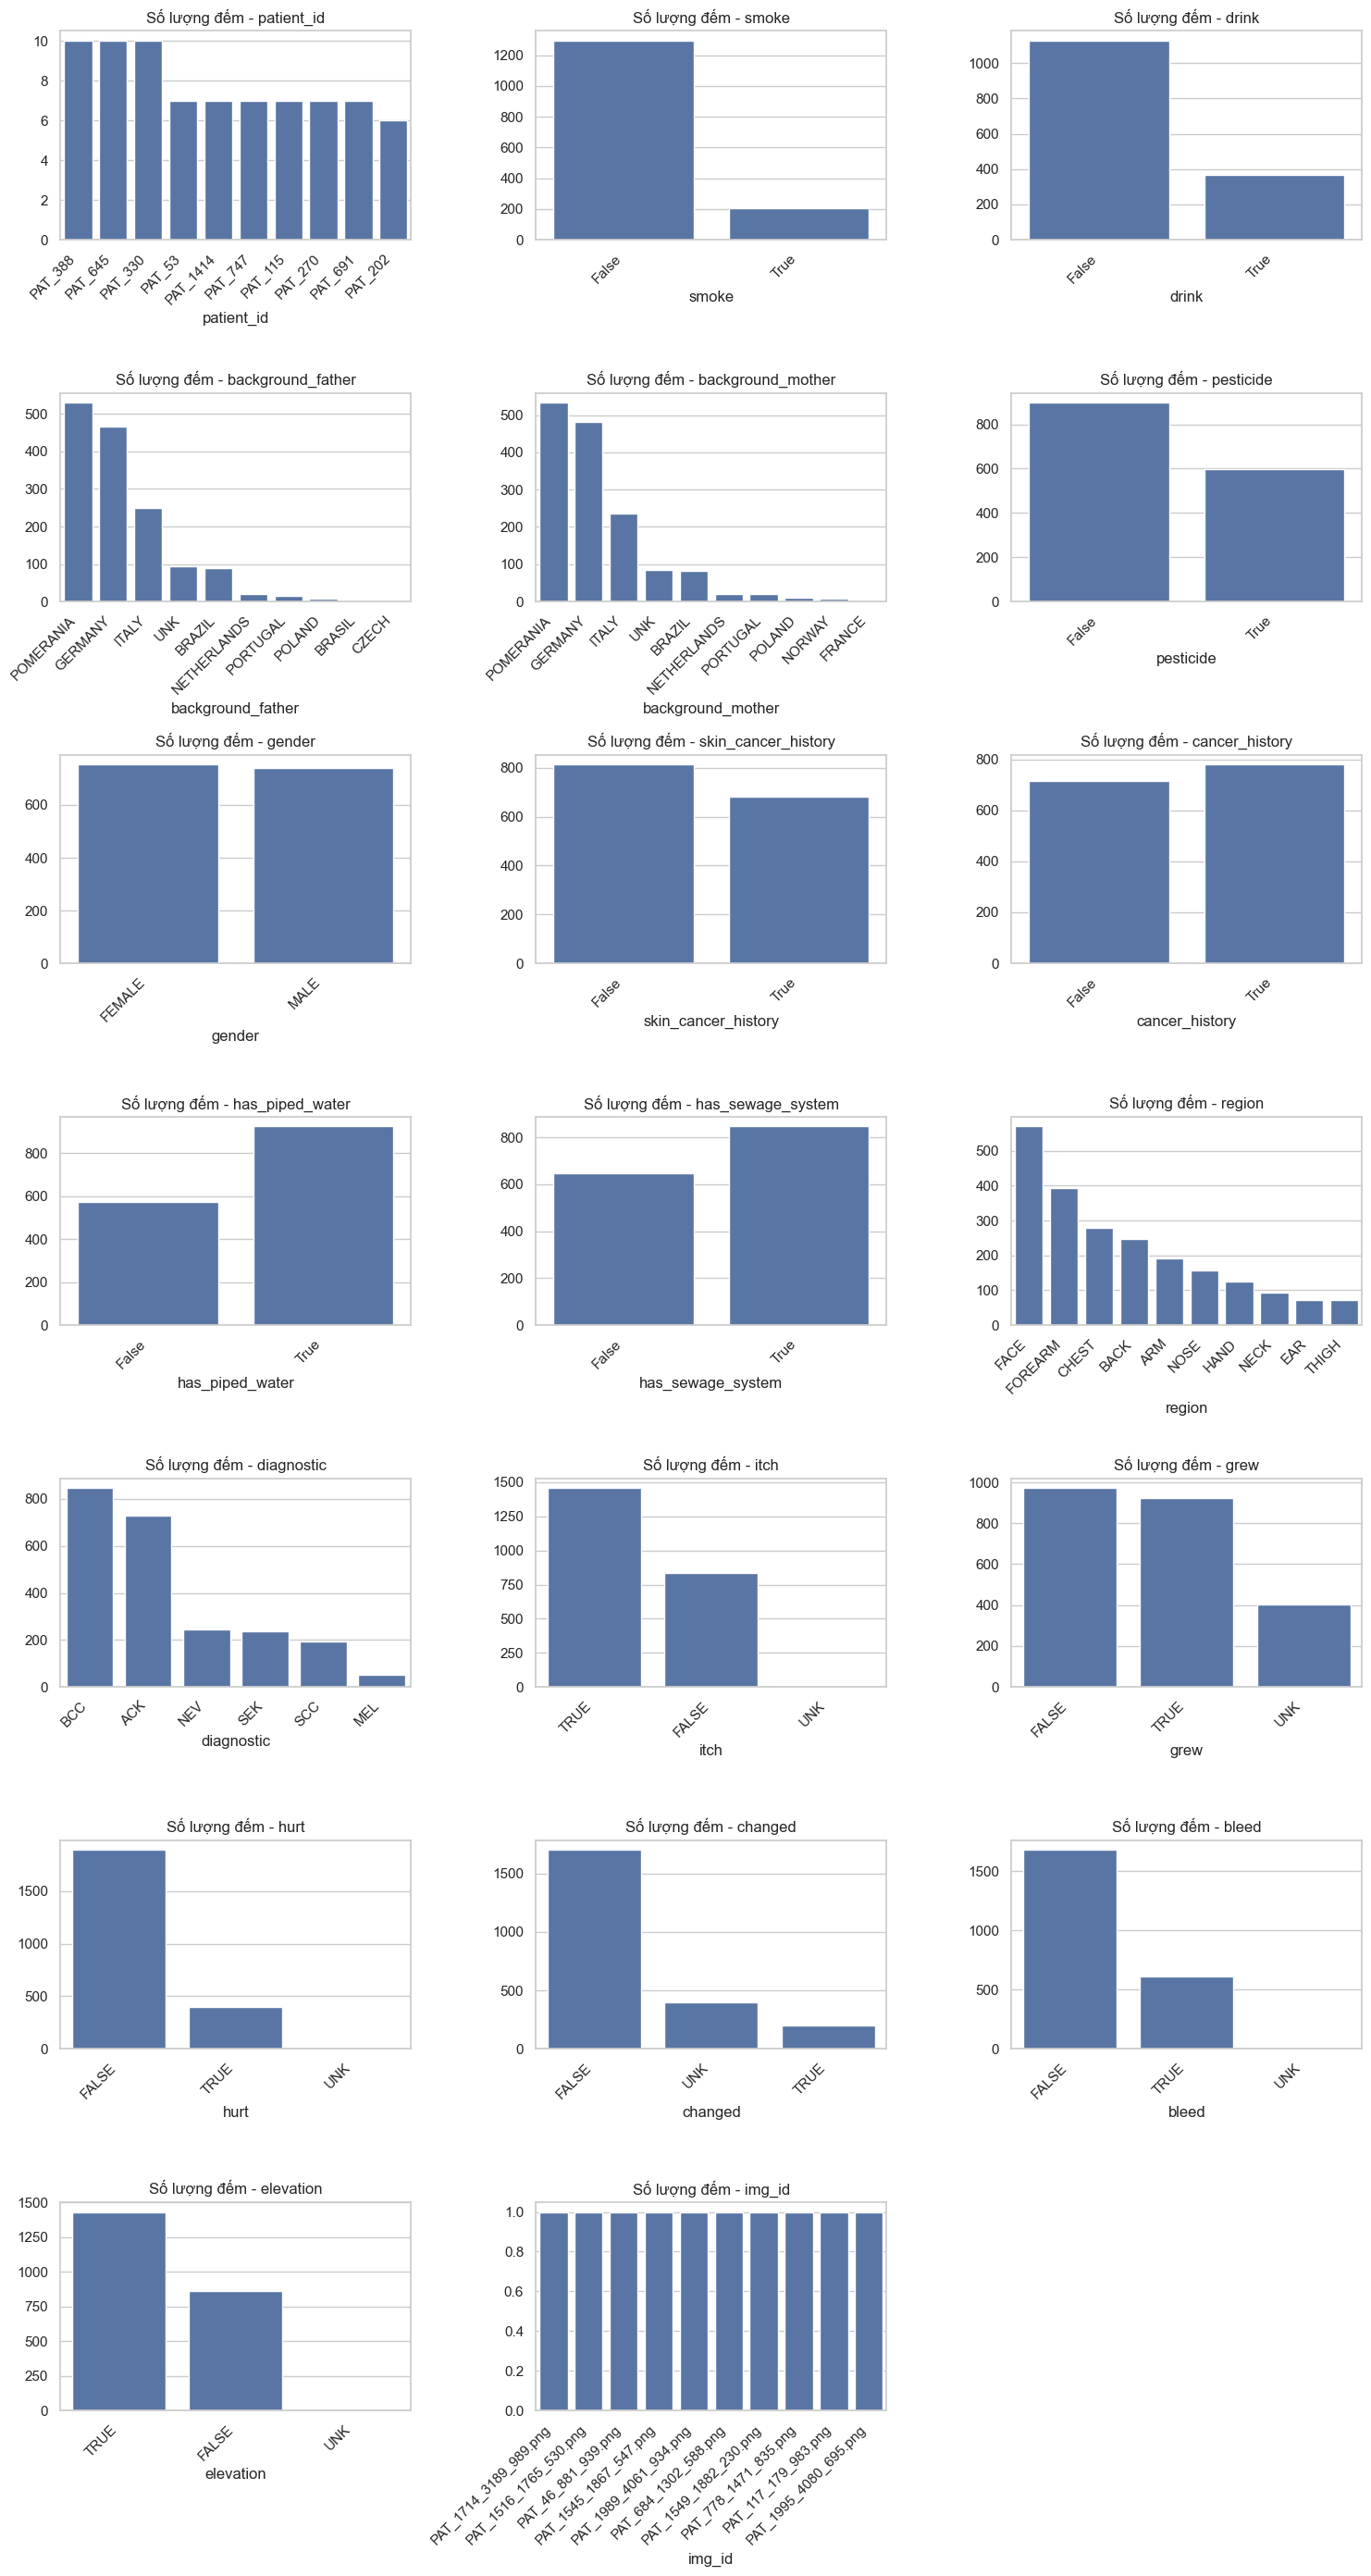

In [4]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print(f"Biến dạng số (Numerical): {list(num_cols)}")
print(f"Biến phân loại (Categorical): {list(cat_cols)}")

# Histplot cho Numerical
if len(num_cols) > 0:
    cols = 3
    rows = (len(num_cols) + cols - 1) // cols
    plt.figure(figsize=(15, rows * 4))
    for i, col in enumerate(num_cols):
        plt.subplot(rows, cols, i + 1)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f'Phân phối của {col}')
    plt.tight_layout()
    plt.show()

# Countplot cho Categorical
if len(cat_cols) > 0:
    cols = 3
    rows = (len(cat_cols) + cols - 1) // cols
    plt.figure(figsize=(15, rows * 4))
    for i, col in enumerate(cat_cols):
        plt.subplot(rows, cols, i + 1)
        val_counts = df[col].value_counts().head(10)
        sns.barplot(x=val_counts.index, y=val_counts.values)
        plt.title(f'Số lượng đếm - {col}')
        plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 4. Kiểm tra Outliers (Boxplot)

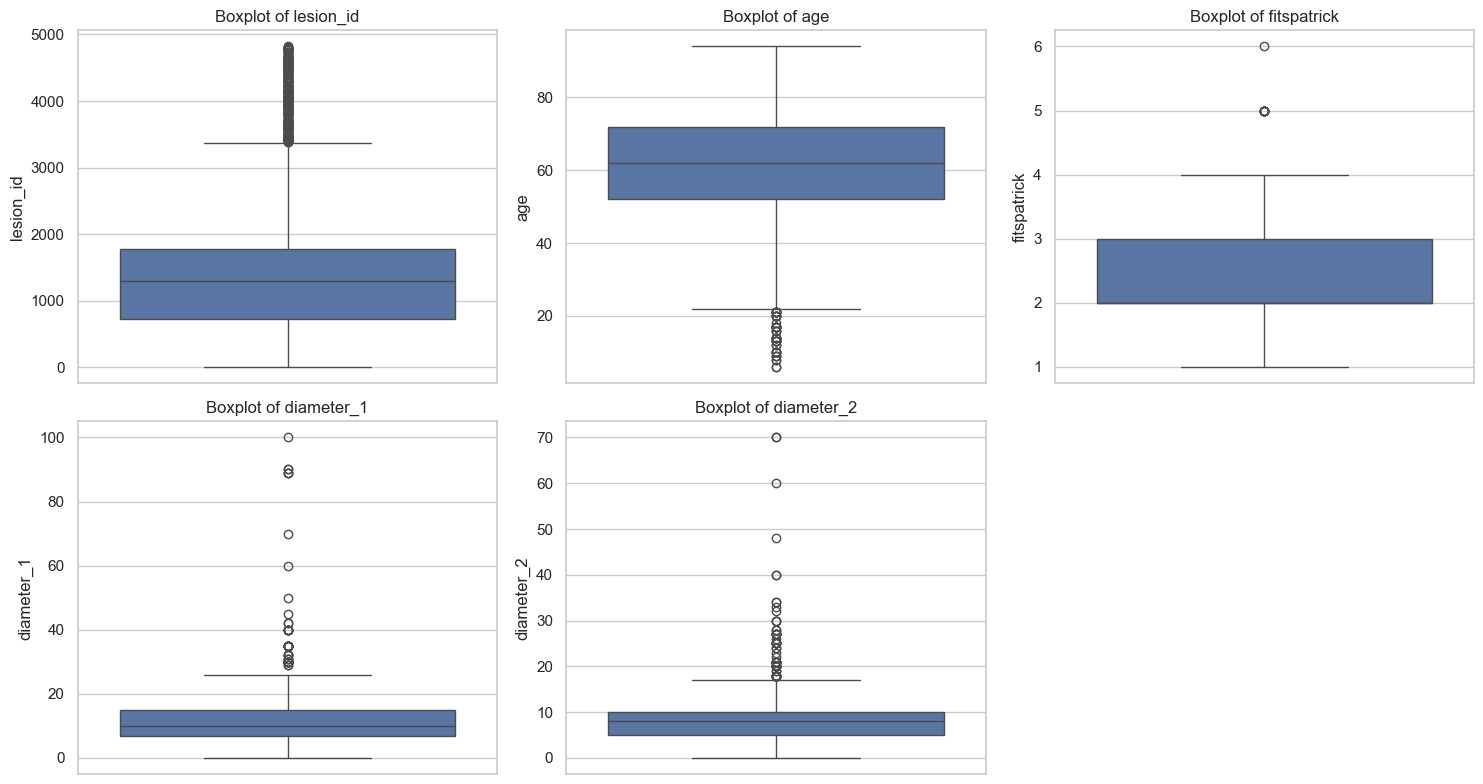

In [5]:
if len(num_cols) > 0:
    cols = 3
    rows = (len(num_cols) + cols - 1) // cols
    plt.figure(figsize=(15, rows * 4))
    for i, col in enumerate(num_cols):
        plt.subplot(rows, cols, i + 1)
        sns.boxplot(y=df[col])
        plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

## 5. Ma trận tương quan (Correlation Matrix)

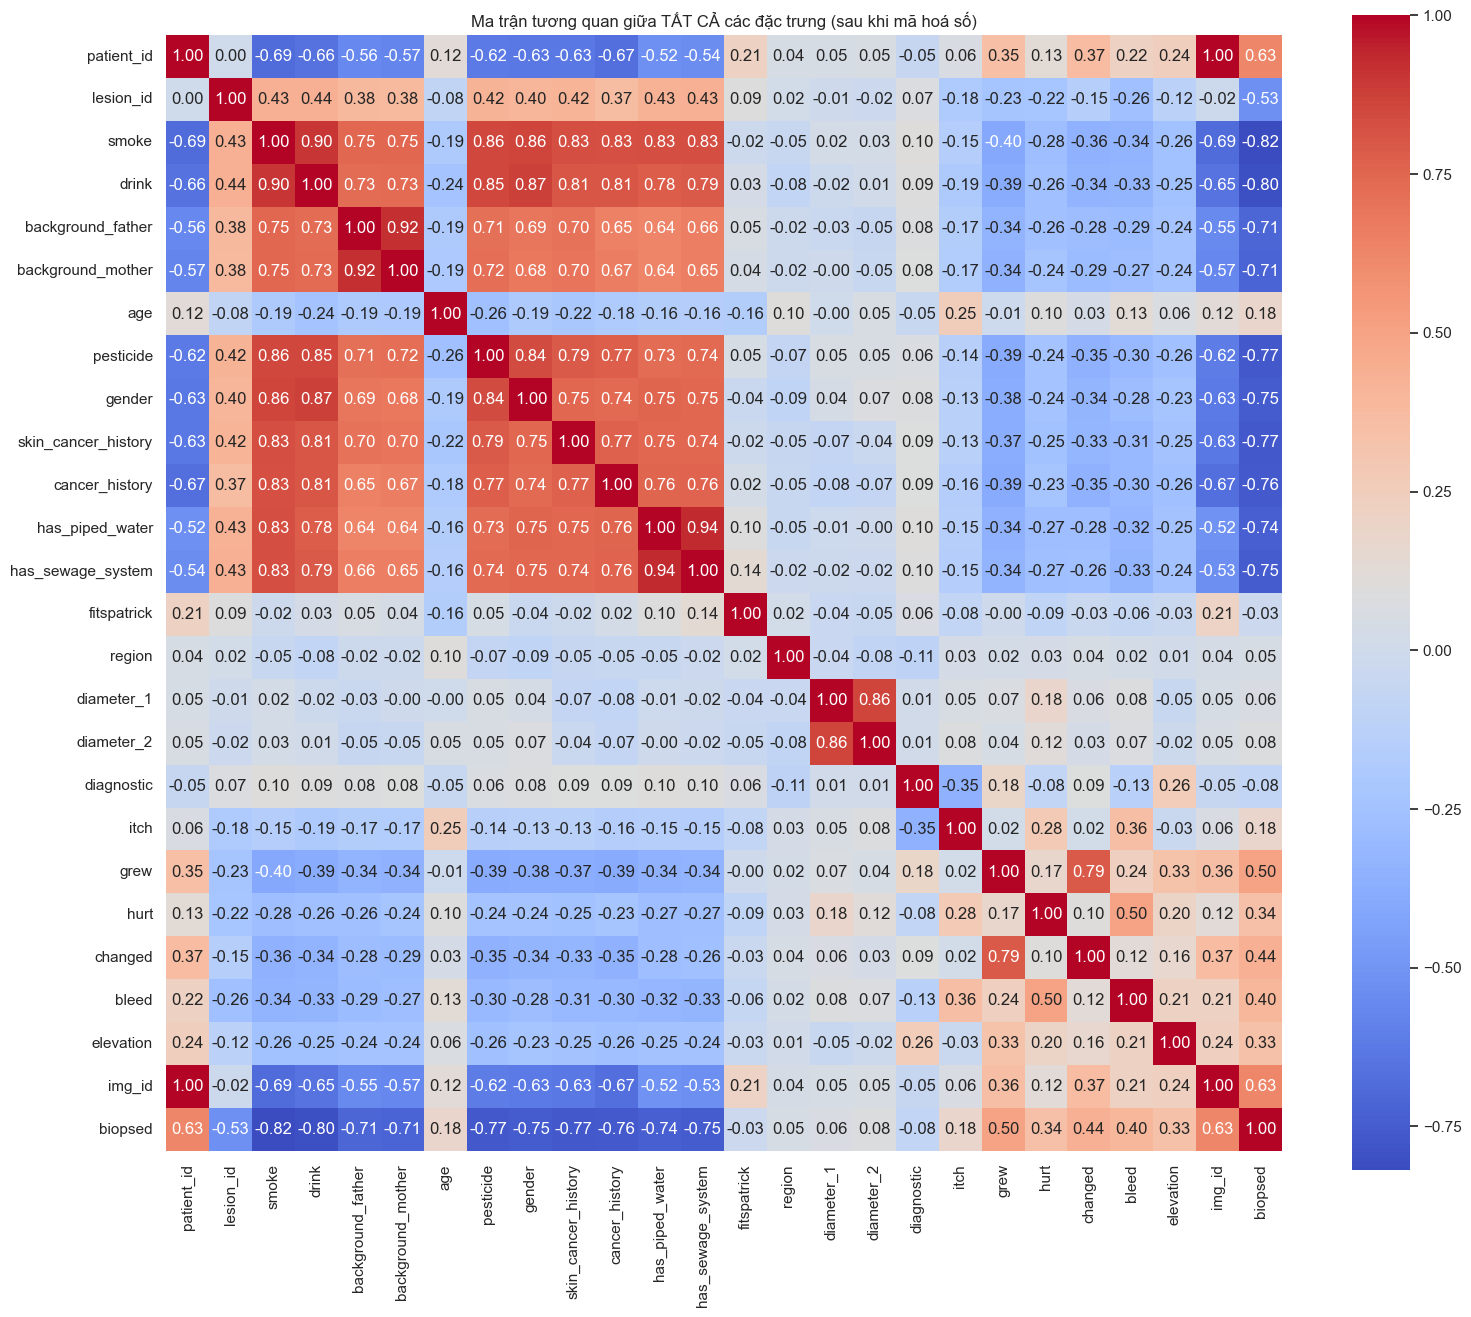

In [6]:
# Tạo bản sao để mã hóa các biến phân loại (categorical), giúp hiển thị đủ 20+ đặc trưng
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

plt.figure(figsize=(18, 15))
corr = df_encoded.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", cbar=True, square=True)
plt.title('Ma trận tương quan giữa TẤT CẢ các đặc trưng (sau khi mã hoá số)')
plt.show()

## 6. Lựa chọn đặc trưng (Feature Selection)
Sau đây ta sẽ sử dụng Mutual Information để tìm ra các đặc trưng quan trọng nhất dự báo cho biến mục tiêu (target variable).

Sử dụng biến mục tiêu: diagnostic


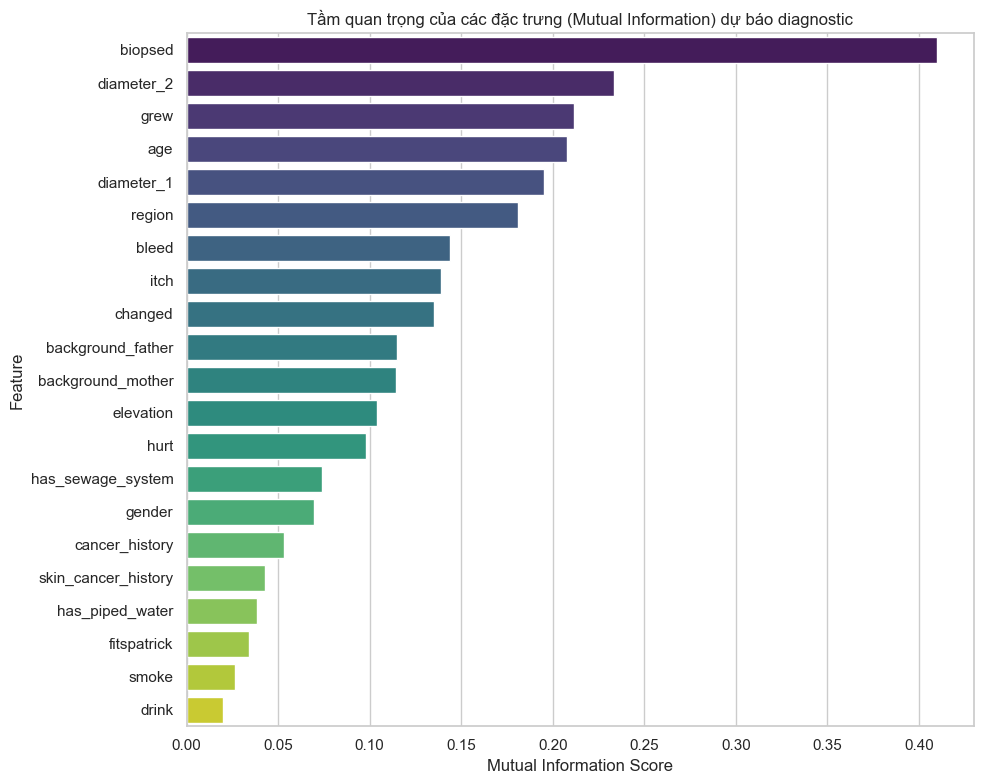

In [ ]:
target_col = 'diagnostic'

if target_col in df.columns:
    print(f"Sử dụng biến mục tiêu: {target_col}")
    
    id_cols = [col for col in df.columns if 'id' in col.lower()]
    df_sel = df.drop(columns=id_cols, errors='ignore')
    
    for col in df_sel.columns:
        if df_sel[col].dtype == 'object':
            fill_val = df_sel[col].mode()[0] if not df_sel[col].mode().empty else 'Unknown'
            df_sel[col] = df_sel[col].fillna(fill_val)
        else:
            df_sel[col] = df_sel[col].fillna(df_sel[col].median())
            
    le = LabelEncoder()
    for col in df_sel.columns:
        if df_sel[col].dtype == 'object':
            df_sel[col] = le.fit_transform(df_sel[col].astype(str))
            
    X = df_sel.drop(columns=[target_col])
    y = df_sel[target_col]
    
    mi_scores = mutual_info_classif(X, y, random_state=42)
    
    mi_df = pd.DataFrame({'Feature': X.columns, 'Mutual_Info_Score': mi_scores})
    mi_df = mi_df.sort_values(by='Mutual_Info_Score', ascending=False)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Mutual_Info_Score', y='Feature', data=mi_df, palette='viridis')
    plt.title(f'Tầm quan trọng của các đặc trưng (Mutual Information) dự báo {target_col}')
    plt.xlabel('Mutual Information Score')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    print(f"Biến mục tiêu '{target_col}' không tồn tại. Vui lòng thử kiểm tra qua các cột đang có: {df.columns.tolist()}")

## 7. Model-based Feature Selection
Sử dụng thêm các mô hình học máy theo ý kiến của bạn, bao gồm:
- **Random Forest** (Tree-based Model)
- **Lasso Regularization** (Embedded Model)
- **SVD** (Dimensionality Reduction)

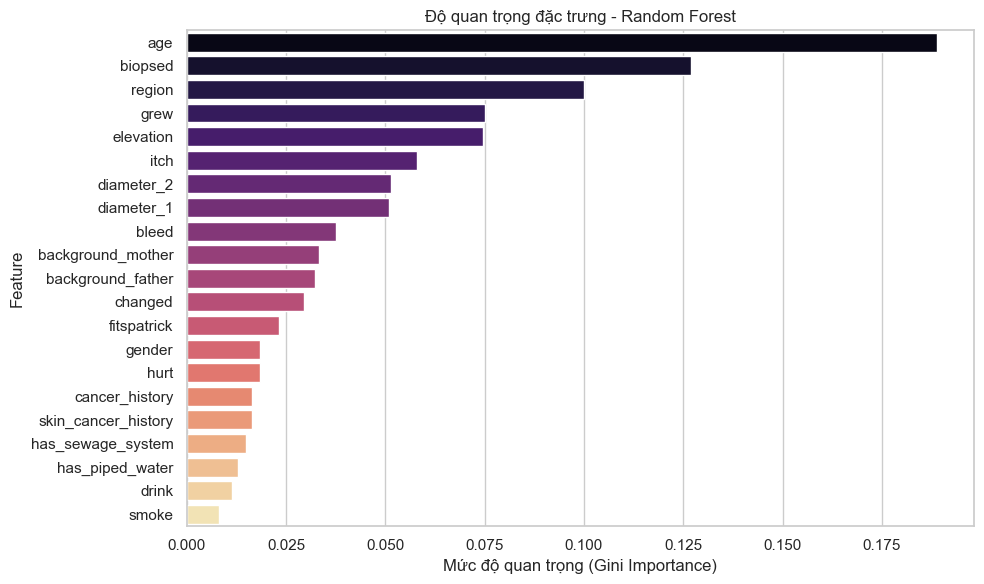

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

# --- 1. Random Forest Feature Importance ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

rf_df = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_})
rf_df = rf_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_df, palette='magma')
plt.title('Độ quan trọng đặc trưng - Random Forest')
plt.xlabel('Mức độ quan trọng (Gini Importance)')
plt.tight_layout()
plt.show()


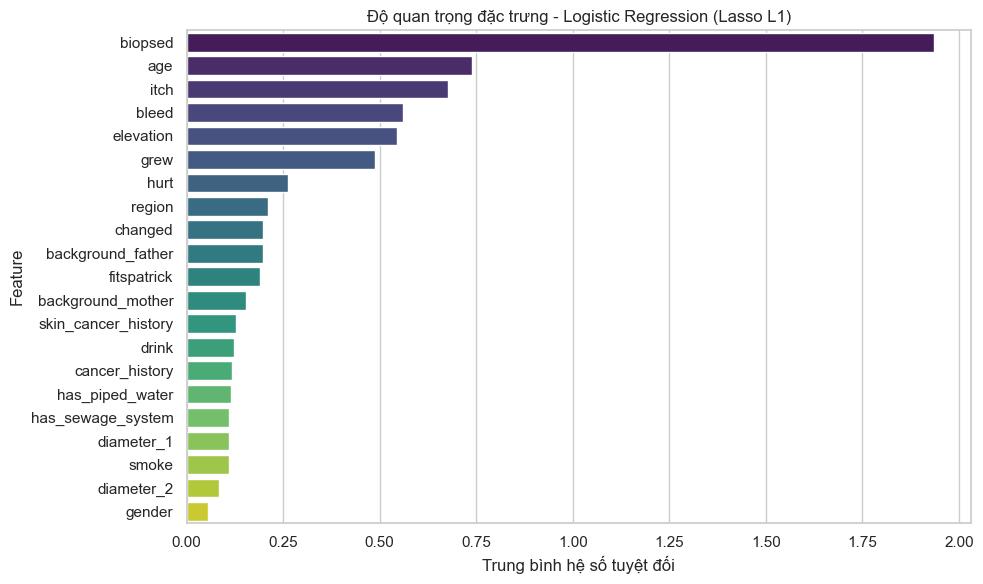

In [ ]:
# --- 2. Lasso Regression (L1 Regularization) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso = LogisticRegression(penalty='l1', solver='liblinear', random_state=42)
lasso.fit(X_scaled, y)

lasso_importance = np.mean(np.abs(lasso.coef_), axis=0)
lasso_df = pd.DataFrame({'Feature': X.columns, 'Importance': lasso_importance})
lasso_df = lasso_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=lasso_df, palette='viridis')
plt.title('Độ quan trọng đặc trưng - Logistic Regression (Lasso L1)')
plt.xlabel('Trung bình hệ số tuyệt đối')
plt.tight_layout()
plt.show()


Tỷ lệ phương sai giải thích bởi 5 dạng SVD components: 0.5274


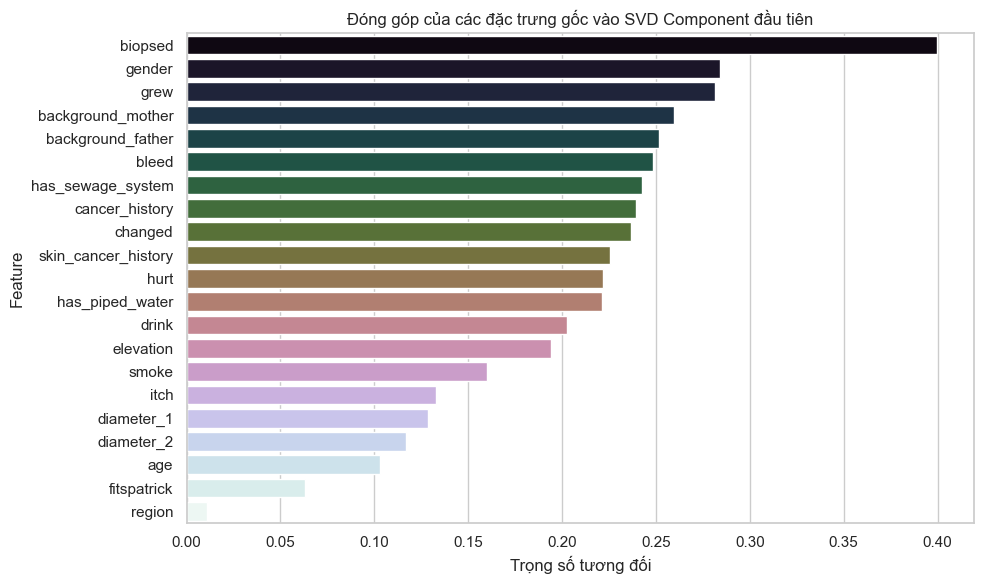

In [ ]:
# --- 3. Singular Value Decomposition (SVD) ---
svd = TruncatedSVD(n_components=5, random_state=42)
X_svd = svd.fit_transform(X_scaled)

print(f"Tỷ lệ phương sai giải thích bởi 5 dạng SVD components: {svd.explained_variance_ratio_.sum():.4f}")

comp1 = pd.DataFrame({'Feature': X.columns, 'Weight': np.abs(svd.components_[0])})
comp1 = comp1.sort_values(by='Weight', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Weight', y='Feature', data=comp1, palette='cubehelix')
plt.title('Đóng góp của các đặc trưng gốc vào SVD Component đầu tiên')
plt.xlabel('Trọng số tương đối')
plt.tight_layout()
plt.show()
